In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier

c:\Users\yasha\OneDrive\Desktop\MiniProjects\predictive-maintenance-platform\backend\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../datasets/ai4i2020.csv")

print(df.shape)

(10000, 14)


In [3]:
X = df.drop(
    columns=[
        "UDI",
        "Product ID",
        "Machine failure",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF",
    ]
)

y = df["Machine failure"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

In [5]:
categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "num",
            SimpleImputer(strategy="median"),
            numerical_features,
        ),
    ]
)

In [6]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Scale pos weight:", scale_pos_weight)

Scale pos weight: 28.52029520295203


In [7]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=500,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                eval_metric="logloss",
            ),
        ),
    ]
)

pipeline.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [8]:
X_train_transformed = pipeline.named_steps[
    "preprocessor"
].transform(X_train)

X_test_transformed = pipeline.named_steps[
    "preprocessor"
].transform(X_test)

print("Transformed training shape:", X_train_transformed.shape)
print("Transformed testing shape:", X_test_transformed.shape)

Transformed training shape: (8000, 8)
Transformed testing shape: (2000, 8)


In [9]:
feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

print(feature_names)

['cat__Type_H' 'cat__Type_L' 'cat__Type_M' 'num__Air temperature [K]'
 'num__Process temperature [K]' 'num__Rotational speed [rpm]'
 'num__Torque [Nm]' 'num__Tool wear [min]']


In [10]:
xgb_model = pipeline.named_steps["classifier"]

print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [11]:
explainer = shap.TreeExplainer(xgb_model)

print("SHAP explainer created.")

SHAP explainer created.


In [12]:
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (2000, 8)


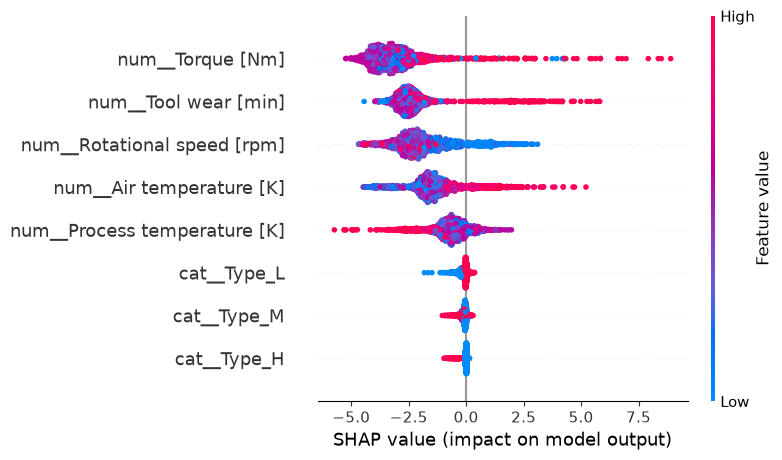

In [13]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
)

In [14]:
import numpy as np

test_probabilities = pipeline.predict_proba(X_test)[:, 1]

high_risk_index = np.argmax(test_probabilities)

print("Test row position:", high_risk_index)
print("Failure probability:", test_probabilities[high_risk_index])
print("Predicted failure:", pipeline.predict(X_test)[high_risk_index])

Test row position: 1225
Failure probability: 0.99984217
Predicted failure: 1


In [15]:
X_test.iloc[high_risk_index]

Type                           L
Air temperature [K]        300.8
Process temperature [K]    309.9
Rotational speed [rpm]      1312
Torque [Nm]                 65.3
Tool wear [min]              192
Name: 6497, dtype: object

In [16]:
shap_explanation = shap.Explanation(
    values=shap_values[high_risk_index],
    base_values=explainer.expected_value,
    data=X_test_transformed[high_risk_index],
    feature_names=feature_names,
)

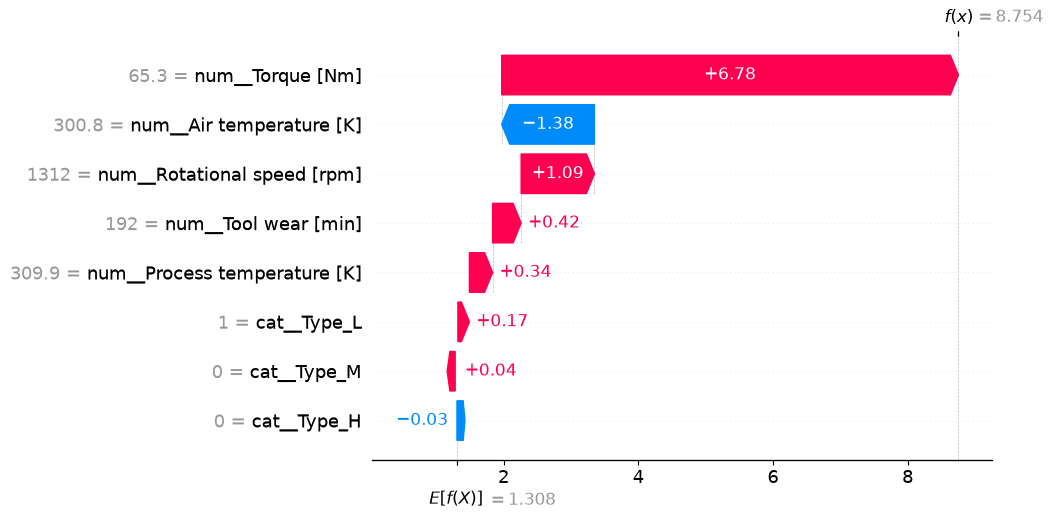

In [17]:
shap.plots.waterfall(shap_explanation)

In [18]:
machine_probability = pipeline.predict_proba(
    X_test.iloc[[high_risk_index]]
)[0][1]

machine_prediction = pipeline.predict(
    X_test.iloc[[high_risk_index]]
)[0]

print(f"Failure probability: {machine_probability:.4f}")
print(f"Failure probability: {machine_probability * 100:.2f}%")
print(f"Predicted failure: {bool(machine_prediction)}")

Failure probability: 0.9998
Failure probability: 99.98%
Predicted failure: True
